In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.1/64.1 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.4/121.4 kB 1.9 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import gensim.downloader as api

# 学習済みのWord2Vecモデルをダウンロードする
print("ダウンロード中...")
model = api.load("word2vec-google-news-300")
print("完了!")
print("語彙数:", len(model))

ダウンロード中...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
完了!
語彙数: 3000000


In [3]:
# 単語をベクトルに変換する
dog_vector = model["dog"]
print("dogのベクトルの次元数:", dog_vector.shape)
print("最初の10次元:", dog_vector[:10].round(4))

dogのベクトルの次元数: (300,)
最初の10次元: [ 0.0513 -0.0223 -0.1729  0.1611 -0.0845  0.0574  0.0586 -0.0825 -0.0154
 -0.0635]


In [4]:
# 意味的に近い単語を探す
print("dogに近い単語:")
for word, score in model.most_similar("dog", topn=5):
    print(f"  {word}: {score:.4f}")

print("\ncatに近い単語:")
for word, score in model.most_similar("cat", topn=5):
    print(f"  {word}: {score:.4f}")

print("\nairplaneに近い単語:")
for word, score in model.most_similar("airplane", topn=5):
    print(f"  {word}: {score:.4f}")

dogに近い単語:
  dogs: 0.8680
  puppy: 0.8106
  pit_bull: 0.7804
  pooch: 0.7627
  cat: 0.7609

catに近い単語:
  cats: 0.8099
  dog: 0.7609
  kitten: 0.7465
  feline: 0.7326
  beagle: 0.7151

airplaneに近い単語:
  plane: 0.8348
  airplanes: 0.7777
  aircraft: 0.7650
  planes: 0.7336
  jet: 0.7162


In [5]:
# 確認してみましょう
print(type(model))

# 辞書のように単語でアクセスできる
print(type(model["dog"]))   # → numpy配列
print(model["dog"].shape)   # → (300,)

<class 'gensim.models.keyedvectors.KeyedVectors'>
<class 'numpy.ndarray'>
(300,)


In [13]:
# most_similarの生の出力を確認する
result = model.most_similar("dog", topn=3)
print(type(result))   # リスト
print(result)         # タプルのリスト
print(result[0])      # 最初のタプル
print(result[0][0])   # 単語
print(result[0][1])   # スコア

for word, vec in result:
    print(f"word: {word}, vec: {vec}")

<class 'list'>
[('dogs', 0.8680489659309387), ('puppy', 0.8106428384780884), ('pit_bull', 0.780396044254303)]
('dogs', 0.8680489659309387)
dogs
0.8680489659309387
word: dogs, vec: 0.8680489659309387
word: puppy, vec: 0.8106428384780884
word: pit_bull, vec: 0.780396044254303


In [8]:
import numpy as np

def cosine_similarity(v1, v2):
    # 内積 ÷ (v1の長さ × v2の長さ)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

dog = model["dog"]
cat = model["cat"]
airplane = model["airplane"]

print("dog と cat の類似度:     ", cosine_similarity(dog, cat).round(4))
print("dog と airplane の類似度:", cosine_similarity(dog, airplane).round(4))

dog と cat の類似度:      0.7609
dog と airplane の類似度: 0.1864


In [9]:
# np.dot(v1, v2)          → 内積（各次元を掛けて足し合わせる）
# np.linalg.norm(v1)      → ベクトルの長さ（ノルム）
# 内積 ÷ (長さ × 長さ)   → コサイン類似度

In [10]:
# 王 - 男 + 女 ≈ 女王
result = model.most_similar(
    positive=["king", "woman"],  # 足す単語
    negative=["man"],            # 引く単語
    topn=3
)

print("king - man + woman =")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman =
  queen: 0.7118
  monarch: 0.6190
  princess: 0.5902


In [11]:
# 日本 - 東京 + パリ ≈ フランス？
result = model.most_similar(
    positive=["Japan", "Paris"],
    negative=["Tokyo"],
    topn=3
)
print("Japan - Tokyo + Paris =")
for word, score in result:
    print(f"  {word}: {score:.4f}")

# 大きい - 大きさ + 速さ ≈ 速い？
result2 = model.most_similar(
    positive=["big", "quickly"],
    negative=["quickly"],
    topn=3
)
print("\nbig - big + quickly =")
for word, score in result2:
    print(f"  {word}: {score:.4f}")

Japan - Tokyo + Paris =
  France: 0.7890
  Belgium: 0.6047
  Italy: 0.5751

big - big + quickly =
  huge: 0.7810
  bigger: 0.6842
  biggest: 0.6337


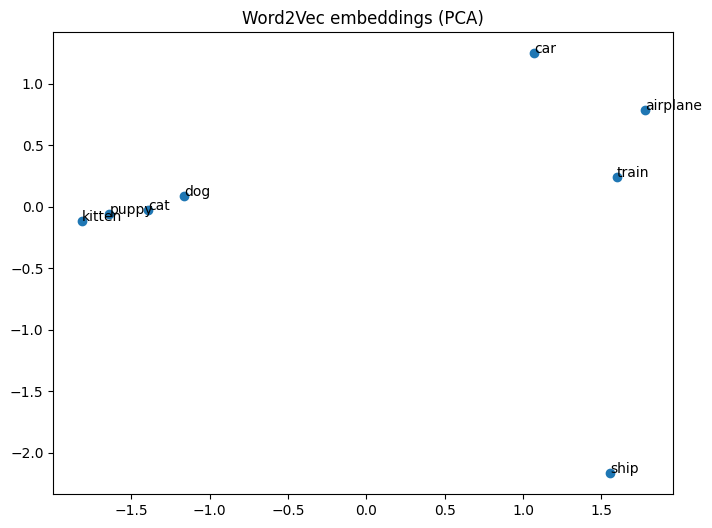

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 確認したい単語
words = ["dog", "cat", "puppy", "kitten",
         "airplane", "car", "train", "ship"]

# 各単語のベクトルを取得
vectors = np.array([model[word] for word in words])

# PCAで300次元→2次元に圧縮
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# プロット
plt.figure(figsize=(8, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("Word2Vec embeddings (PCA)")
plt.show()